In [8]:
import pandas as pd
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv('Resume.csv')

In [10]:
columns_to_keep = ['Resume', 'Category', 'ID']

In [11]:
df = df[columns_to_keep]

In [12]:
df.shape

(3474, 3)

In [13]:
df.head()

,Resume,Category,ID
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,16852973
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,22323967
2,HR DIRECTOR Summary Over 2...,HR,33176873
3,HR SPECIALIST Summary Dedica...,HR,27018550
4,HR MANAGER Skill Highlights ...,HR,17812897


In [14]:
df['Resume'] = df['Resume'].fillna('')
df['Category'] = df['Category'].fillna('Software Developer')

In [15]:
df.drop_duplicates(subset=['Resume'], inplace=True)

In [16]:
stop_words = ENGLISH_STOP_WORDS

def clean_text(text):
    text = re.sub(r'<.*?>', '', str(text))
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    tokens = [word for word in text.split() if word not in stop_words]
    return ' '.join(tokens)

In [17]:
df['Cleaned_Resume'] = df['Resume'].apply(clean_text)

In [18]:
df['Cleaned_Resume']

,Cleaned_Resume
0,hr administrator marketing associate hr admini...
1,hr specialist hr operations summary versatile ...
2,hr director summary years experience recruitin...
3,hr specialist summary dedicated driven dynamic...
4,hr manager skill highlights hr skills hr depar...
...,...
3468,advanced level wheeled vehicle mechanic career...
3469,rank sgt e non commissioned officer charge bri...
3470,government relations communications organizati...
3471,geek squad agent professional profile support ...


In [19]:
X = df['Cleaned_Resume']
y = df['Category']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [22]:
# Logistic Regression
log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_tfidf, y_train)
log_pred = log_model.predict(X_test_tfidf)

In [23]:
# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)

In [24]:
# SVM
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)

In [25]:
print("🔹 Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
#print(classification_report(y_test, log_pred))

print("🔹 Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
#print(classification_report(y_test, nb_pred))

print("🔹 SVM Accuracy:", accuracy_score(y_test, svm_pred))
#print(classification_report(y_test, svm_pred))


🔹 Logistic Regression Accuracy: 0.6423076923076924
🔹 Naive Bayes Accuracy: 0.5365384615384615
🔹 SVM Accuracy: 0.6884615384615385


In [26]:
best_model = svm_model

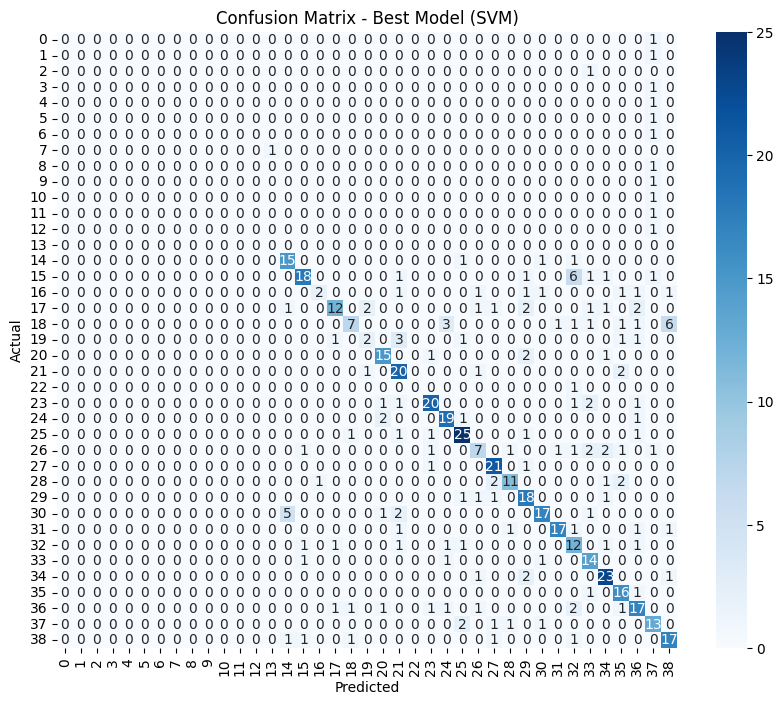

In [27]:
y_pred = best_model.predict(X_test_tfidf)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Best Model (SVM)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
joblib.dump(best_model, "Dataset1.pkl")
joblib.dump(tfidf, "tfidf_Dataset1.pkl")

print("\n✅ Model and Vectorizer saved successfully!")


✅ Model and Vectorizer saved successfully!


In [29]:
def predict_job_role(text):
    """Predicts the job role from a given job description."""
    clean = clean_text(text)
    vector = tfidf.transform([clean])
    return best_model.predict(vector)[0]

In [30]:
# Example Prediction
print("Job Description:")
sample = input()
#print(sample)
print("Predicted Role:", predict_job_role(sample))

Job Description:
Data Analyst skilled in SQL, Python, and Power BI. The role involves cleaning, analyzing, and visualizing large datasets to generate business insights.
Predicted Role: Software Developer
